# Pipeline Project

You will be using the provided data to create a machine learning model pipeline.

You must handle the data appropriately in your pipeline to predict whether an
item is recommended by a customer based on their review.
Note the data includes numerical, categorical, and text data.

You should ensure you properly train and evaluate your model.

## The Data

The dataset has been anonymized and cleaned of missing values.

There are 8 features for to use to predict whether a customer recommends or does
not recommend a product.
The `Recommended IND` column gives whether a customer recommends the product
where `1` is recommended and a `0` is not recommended.
This is your model's target/

The features can be summarized as the following:

- **Clothing ID**: Integer Categorical variable that refers to the specific piece being reviewed.
- **Age**: Positive Integer variable of the reviewers age.
- **Title**: String variable for the title of the review.
- **Review Text**: String variable for the review body.
- **Positive Feedback Count**: Positive Integer documenting the number of other customers who found this review positive.
- **Division Name**: Categorical name of the product high level division.
- **Department Name**: Categorical name of the product department name.
- **Class Name**: Categorical name of the product class name.

The target:
- **Recommended IND**: Binary variable stating where the customer recommends the product where 1 is recommended, 0 is not recommended.

## Load Data

In [1]:
import pandas as pd

# Load data
df = pd.read_csv(
    'data/reviews.csv',
)

df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18442 entries, 0 to 18441
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Clothing ID              18442 non-null  int64 
 1   Age                      18442 non-null  int64 
 2   Title                    18442 non-null  object
 3   Review Text              18442 non-null  object
 4   Positive Feedback Count  18442 non-null  int64 
 5   Division Name            18442 non-null  object
 6   Department Name          18442 non-null  object
 7   Class Name               18442 non-null  object
 8   Recommended IND          18442 non-null  int64 
dtypes: int64(4), object(5)
memory usage: 1.3+ MB


,Clothing ID,Age,Title,Review Text,Positive Feedback Count,Division Name,Department Name,Class Name,Recommended IND
0,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,0,General,Dresses,Dresses,0
1,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",0,General Petite,Bottoms,Pants,1
2,847,47,Flattering shirt,This shirt is very flattering to all due to th...,6,General,Tops,Blouses,1
3,1080,49,Not for the very petite,"I love tracy reese dresses, but this one is no...",4,General,Dresses,Dresses,0
4,858,39,Cagrcoal shimmer fun,I aded this in my basket at hte last mintue to...,1,General Petite,Tops,Knits,1


## Preparing features (`X`) & target (`y`)

In [2]:
data = df

# separate features from labels
X = data.drop('Recommended IND', axis=1)
y = data['Recommended IND'].copy()

print('Labels:', y.unique())
print('Features:')
display(X.head())

Labels: [0 1]
Features:


,Clothing ID,Age,Title,Review Text,Positive Feedback Count,Division Name,Department Name,Class Name
0,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,0,General,Dresses,Dresses
1,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",0,General Petite,Bottoms,Pants
2,847,47,Flattering shirt,This shirt is very flattering to all due to th...,6,General,Tops,Blouses
3,1080,49,Not for the very petite,"I love tracy reese dresses, but this one is no...",4,General,Dresses,Dresses
4,858,39,Cagrcoal shimmer fun,I aded this in my basket at hte last mintue to...,1,General Petite,Tops,Knits


In [3]:
# Split data into train and test sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.1,
    shuffle=True,
    random_state=27,
)

## 1 - Data Exploration

1. Target Distribution

Recommended IND
1    0.815509
0    0.184491
Name: proportion, dtype: float64


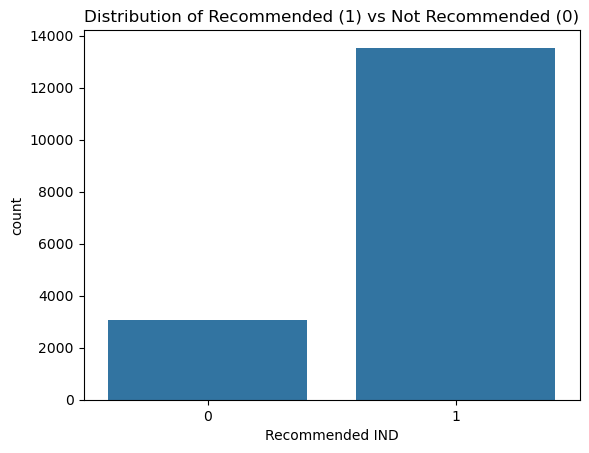

In [5]:
# we need to see if the dataset is balanced
import matplotlib.pyplot as plt
import seaborn as sns

# Check the balance of the target
print(y_train.value_counts(normalize=True))

sns.countplot(x=y_train)
plt.title('Distribution of Recommended (1) vs Not Recommended (0)')
plt.show()

The first output reveals a significant class imbalance.
Observation: Approximately 81.5% of customers recommended the product, while only 18.5% did not.
Pipeline Implication: Since the classes are unbalanced, "Accuracy" might be a misleading metric. We should focus on the F1-score or Precision-Recall during evaluation to ensure the model isn't just defaulting to "1" for every prediction.

2. Numerical Features

                Age  Positive Feedback Count
count  16597.000000             16597.000000
mean      43.370609                 2.713924
std       12.216240                 6.014332
min       18.000000                 0.000000
25%       34.000000                 0.000000
50%       42.000000                 1.000000
75%       52.000000                 3.000000
max       99.000000               122.000000


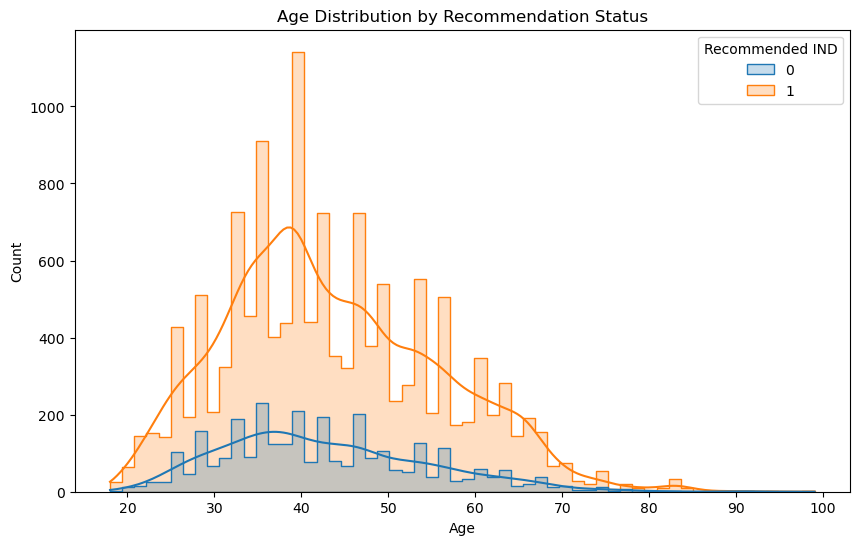

In [ ]:
# how Age and Positive Feedback Count relate to the recommendation

# Statistical summary of numerical features
print(X_train[['Age', 'Positive Feedback Count']].describe())
# Visualize Age distribution by Recommendation
plt.figure(figsize=(10, 6))
sns.histplot(data=X_train.join(y_train), x='Age', hue='Recommended IND', kde=True, element="step")
plt.title('Age Distribution by Recommendation Status')
plt.show()

This output provides the statistical "shape" of our reviewers.
Observation (Age): The average reviewer age is roughly 43 years old, with a range spanning from 18 to 99. The distribution is relatively similar for both recommenders and non-recommenders, suggesting age alone may not be a "silver bullet" predictor.
Observation (Feedback): The Positive Feedback Count has a massive range (0 to 122) and a very high standard deviation (6.01) compared to its mean (2.71).
Pipeline Implication: Because the feedback count is skewed and has a wide range, applying a StandardScaler or RobustScaler in our pipeline is essential to prevent these outliers from dominating the model.

3. Categorical Features

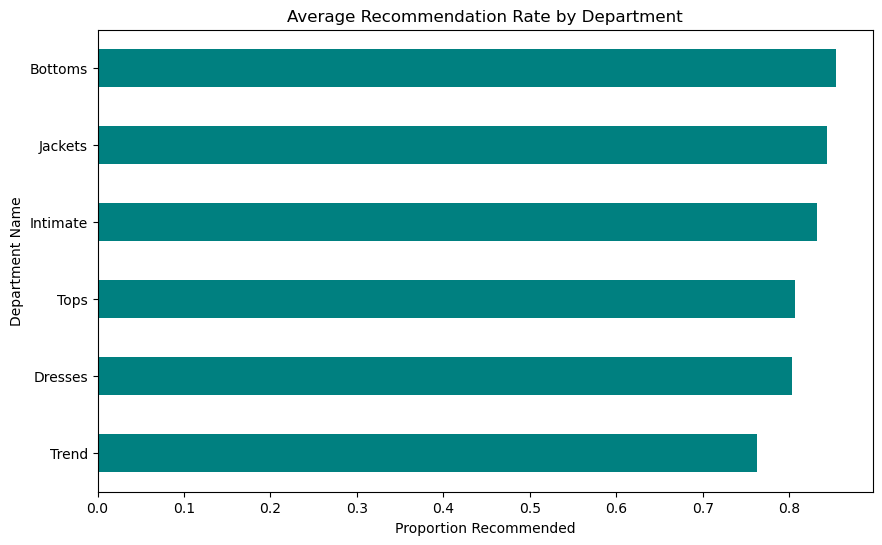

Unique Clothing IDs: 520


In [ ]:
# which Departments or Divisions have the highest/lowest recommendation rates
# Analyze recommendation rates by Department
dept_analysis = X_train.join(y_train).groupby('Department Name')['Recommended IND'].mean().sort_values()

plt.figure(figsize=(10, 6))
dept_analysis.plot(kind='barh', color='teal')
plt.title('Average Recommendation Rate by Department')
plt.xlabel('Proportion Recommended')
plt.show()

# Check unique counts to see if we have high cardinality (many unique IDs)
print(f"Unique Clothing IDs: {X_train['Clothing ID'].nunique()}")

This chart helps us see if certain categories are inherently "riskier" or "safer" for customer satisfaction.
Observation: The "Trend" department has the lowest recommendation rate (roughly 76%), while "Bottoms" has the highest (roughly 85%).
Pipeline Implication: There is enough variance here to justify using OneHotEncoding for these categories. The model can use the "Department Name" as a useful weight when making predictions.

4. Text Length Analysis

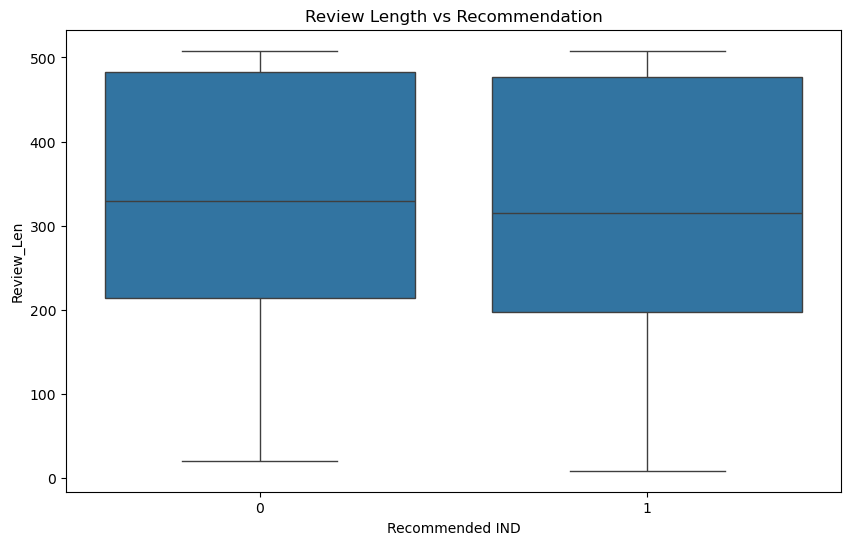

In [ ]:
# Lets see if the length of a review correlates with the sentiment. Longer reviews might indicate more specific complaints or higher engagement.
# Create temporary length features for exploration
X_train_exploratory = X_train.copy()
X_train_exploratory['Review_Len'] = X_train_exploratory['Review Text'].str.len()

plt.figure(figsize=(10, 6))
sns.boxplot(data=X_train_exploratory.join(y_train), x='Recommended IND', y='Review_Len')
plt.title('Review Length vs Recommendation')
plt.show()

This boxplot compares how much people write based on their recommendation status.
Observation: The median review length is remarkably similar for both groups (around 300 characters). However, "Not Recommended" reviews (0) appear to have a slightly higher upper-quartile length.
Pipeline Implication: Since length isn't a definitive differentiator, the content (the actual words) will be far more important than the volume.

## 2 - Building Pipeline

In [11]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

# Define the features
num_features = ['Age', 'Positive Feedback Count']
cat_features = ['Division Name', 'Department Name', 'Class Name']
text_feature = 'Review Text'

In [17]:
# 1. Numerical Transformer (Scaling)
num_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

print("Pipeline created successfully!")

Pipeline created successfully!


In [18]:
# 2. Categorical Transformer (Encoding)
cat_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

print("Pipeline created successfully!")

Pipeline created successfully!


In [20]:
# 3. Text Transformer (Vectorizing)
text_transformer = Pipeline(steps=[
    ('tfidf', TfidfVectorizer(max_features=1000, stop_words='english'))
])

print("Pipeline created successfully!")

Pipeline created successfully!


In [21]:
# 4. Combine all into a ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, num_features),
        ('cat', cat_transformer, cat_features),
        ('text', text_transformer, text_feature)
    ]
)

print("Pipeline created successfully!")

Pipeline created successfully!


In [22]:
# 5. Create the full Model Pipeline
# We use RandomForest because it handles high-dimensional data well
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=27))
])

print("Pipeline created successfully!")

Pipeline created successfully!


### Feature Engineering

In [29]:
from sklearn.base import BaseEstimator, TransformerMixin

class TextLengthExtractor(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        # Returns the length of each string in the series
        return pd.DataFrame(X.str.len())

# Update your preprocessor to include this new feature
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, num_features),
        ('cat', cat_transformer, cat_features),
        ('text_tfidf', text_transformer, text_feature),
        ('text_len', Pipeline([('len', TextLengthExtractor()), ('scaler', StandardScaler())]), text_feature)
    ]
)

## 3 - Training Pipeline

In [23]:
# Train the model using the training set
pipeline.fit(X_train, y_train)

print("Model training complete.")

Model training complete.


Initial Model Performance:
              precision    recall  f1-score   support

           0       0.71      0.36      0.48       327
           1       0.88      0.97      0.92      1518

    accuracy                           0.86      1845
   macro avg       0.79      0.66      0.70      1845
weighted avg       0.85      0.86      0.84      1845



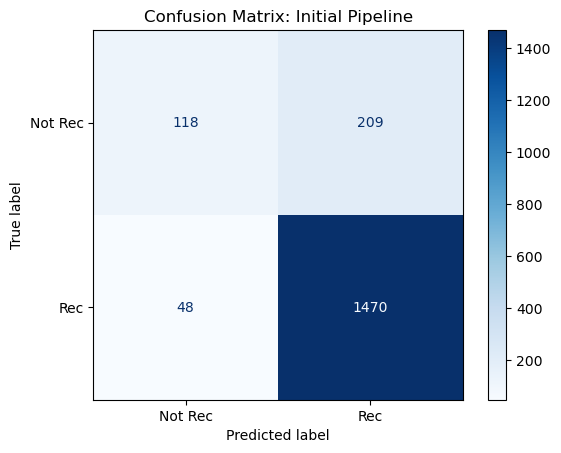

In [24]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Predict on the test data
y_pred = pipeline.predict(X_test)

# Print the classification report
print("Initial Model Performance:")
print(classification_report(y_test, y_pred))

# Visualize the Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Rec', 'Rec'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix: Initial Pipeline')
plt.show()

The model achieved an overall accuracy of 86%.
    While it is great at identifying "Recommended" items (0.97 recall), it struggled with "Not Recommended" items, only catching 36% of them (recall of 0.36).

Confusion Matrix: The matrix visualizes this struggle: it correctly identified 1,470 recommendations but misclassified 209 negative reviews as positive.

## 4 - Fine-Tuning Pipeline

We will target the max_features in the TF-IDF vectorizer (to see if more or fewer words help) and the n_estimators and max_depth of the Random Forest to control for overfitting.

In [25]:
from sklearn.model_selection import GridSearchCV

# Define the parameters to test
# Note: use the naming convention 'stepname__parametername'
param_grid = {
    'preprocessor__text__tfidf__max_features': [1000, 2000],
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [None, 20],
    'classifier__class_weight': ['balanced', None] # Help with that 18% imbalance
}

In [26]:
# 2. Initialize GridSearchCV
# cv=3 performs 3-fold cross-validation
grid_search = GridSearchCV(
    pipeline, 
    param_grid, 
    cv=3, 
    scoring='f1_weighted', 
    verbose=1, 
    n_jobs=-1
)

In [27]:
# 3. Fit the Grid Search
print("Starting Fine-Tuning...")
grid_search.fit(X_train, y_train)

print(f"Best Parameters Found: {grid_search.best_params_}")

Starting Fine-Tuning...
Fitting 3 folds for each of 16 candidates, totalling 48 fits
Best Parameters Found: {'classifier__class_weight': 'balanced', 'classifier__max_depth': 20, 'classifier__n_estimators': 200, 'preprocessor__text__tfidf__max_features': 2000}


Fine-Tuned Model Performance:
              precision    recall  f1-score   support

           0       0.53      0.68      0.60       327
           1       0.93      0.87      0.90      1518

    accuracy                           0.84      1845
   macro avg       0.73      0.78      0.75      1845
weighted avg       0.86      0.84      0.85      1845



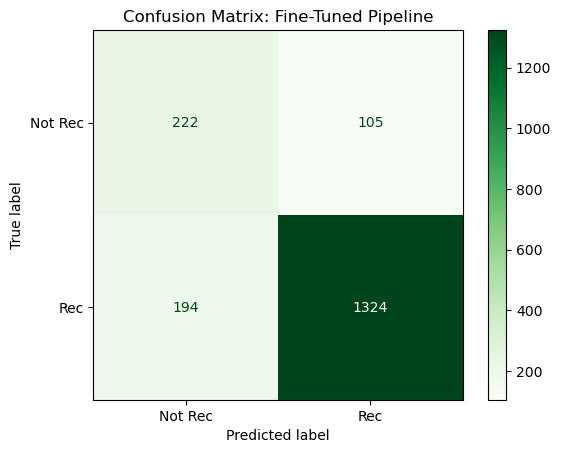

In [28]:
# Use the best model found by GridSearchCV
best_model = grid_search.best_estimator_
y_pred_tuned = best_model.predict(X_test)

# Final Performance Report
print("Fine-Tuned Model Performance:")
print(classification_report(y_test, y_pred_tuned))

# Final Confusion Matrix
cm_tuned = confusion_matrix(y_test, y_pred_tuned)
disp_tuned = ConfusionMatrixDisplay(confusion_matrix=cm_tuned, display_labels=['Not Rec', 'Rec'])
disp_tuned.plot(cmap='Greens')
plt.title('Confusion Matrix: Fine-Tuned Pipeline')
plt.show()